In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
from neuralnet import avg_fidelity_loss, avg_norm_loss 
import math

from dataGenNew import generate_random_function, Ugen, rand_En, rand_costheta, rand_phi, full_measure

#from dataGenNew import generate_random_function, Ugen, rand_En, rand_costheta, rand_phi, full_measure
import tensorflow as tf
import time 

Model: "spiffyfaf"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 5  0           []                               
                                )]                                                                
                                                                                                  
 sequential (Sequential)        (None, 128, 128, 32  1536        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 max_pooling2d (MaxPooling2D)   (None, 64, 64, 32)   0           ['sequential[0][0]']             
                                                                                          

Load up trained models

In [3]:
# Load model checkpoint 
num_pix = 64

old_mol = 'nn_5_neo'
new_mol = 'network16_nopi_30'

new_mol_32 = 'network32'
new_mol_64 = 'network64_30'
new_mol_128 = 'network128_8batch'

loaded_model = tf.keras.models.load_model(new_mol_64, custom_objects={'math': math, 'minMean': avg_fidelity_loss, 'minMeanNormal':avg_norm_loss}, compile=True)
#loaded_model.summary()

# Sample at random points from the Bloch Sphere

In [74]:
# array of zeros (just to test)

n_coeff = 1
num_pix = 64

zer = np.zeros((num_pix,num_pix))

func = lambda x: np.tanh(5*x)

fac=np.random.uniform(0,0.00001)
#fac = 1


a1=rand_En(n_coeff,num_pix)
a2=(np.arccos(rand_costheta(n_coeff,num_pix)))
#a2 = func(a2)*np.pi
a3=rand_phi(n_coeff,num_pix)


if a2[0,0]>np.pi/2: #make sure the first pixel has nz>0
    a2=np.pi-a2



In [100]:
# How well does our network generalize to noisy data? 

noise = 0.01

full_meas=full_measure(a1,a2,a3,num_pix,noise)
print(np.shape(full_meas))


full_meas_enhance = tf.expand_dims(full_meas, axis=0)
print(np.shape(full_meas_enhance))


(64, 64, 5)
(1, 64, 64, 5)


# Make subplots of input data 

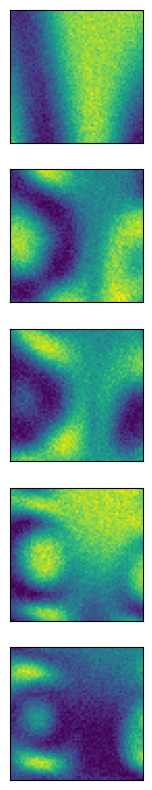

In [93]:
fig, ax = plt.subplots(5,1, figsize=(2,10))


ax[0].imshow(full_meas[:,:,0]) 
ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

ax[1].imshow(full_meas[:,:,1]) 
ax[1].get_xaxis().set_visible(False)
ax[1].get_yaxis().set_visible(False)

ax[2].imshow(full_meas[:,:,2]) 
ax[2].get_xaxis().set_visible(False)
ax[2].get_yaxis().set_visible(False)

ax[3].imshow(full_meas[:,:,3])
ax[3].get_xaxis().set_visible(False)
ax[3].get_yaxis().set_visible(False)

ax[4].imshow(full_meas[:,:,4])
ax[4].get_xaxis().set_visible(False)
ax[4].get_yaxis().set_visible(False)

plt.savefig('inputMeas.png')

# Make subplots of output data 

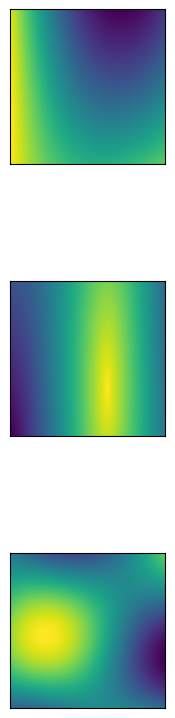

In [77]:
fig, ax = plt.subplots(3,1, figsize=(2,10))

ax[0].imshow(a1) 
ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

ax[1].imshow(a2) 
ax[1].get_xaxis().set_visible(False)
ax[1].get_yaxis().set_visible(False)

ax[2].imshow(a3) 
ax[2].get_xaxis().set_visible(False)
ax[2].get_yaxis().set_visible(False)

plt.savefig('outputMeas.png')

In [8]:
num_pix=32

# Let's now consider some synthetic experiments

In [72]:
direc_1 = [f'synthetic_experiments_32/{ii}/' for ii in range(1,9)] # Synthetic experiments
synth = 5

if (synth==5):
    a2 = np.ones((num_pix,num_pix))*np.pi/2
else:
    a2 = np.loadtxt(direc_1[synth-1]+'theta.txt')
    
a1 = np.loadtxt(direc_1[synth-1]+'en.txt')
a3 = np.loadtxt(direc_1[synth-1]+'phi.txt')

LL = np.loadtxt(direc_1[synth-1]+'LL.txt')
LH = np.loadtxt(direc_1[synth-1]+'LH.txt')
LD = np.loadtxt(direc_1[synth-1]+'LD.txt')
HH = np.loadtxt(direc_1[synth-1]+'HH.txt')
HD = np.loadtxt(direc_1[synth-1]+'HD.txt')

full_meas = np.empty((num_pix,num_pix,5))

for i in range(num_pix):
    for j in range(num_pix):
        full_meas[i,j,0] = LL[i,j]
        full_meas[i,j,1] = LH[i,j]
        full_meas[i,j,2] = LD[i,j]
        full_meas[i,j,3] = HH[i,j]
        full_meas[i,j,4] = HD[i,j]


full_meas_enhance = tf.expand_dims(full_meas, axis=0)

IndexError: index 32 is out of bounds for axis 1 with size 32

# Now we prompt the network to make predictions

In [73]:
np.shape(a1)

(32, 32)

In [94]:

start_time = time.time()
y_pred=loaded_model.predict(full_meas_enhance)
fin_time = time.time() - start_time
print(fin_time)
np.shape(y_pred)

En_vect = y_pred[0,:,:,0]
nx_vect = np.sin(y_pred[0,:,:,1])*np.cos(y_pred[0,:,:,2])
ny_vect = np.sin(y_pred[0,:,:,1])*np.sin(y_pred[0,:,:,2])
nz_vect = np.cos(y_pred[0,:,:,1])

1/1 [==============================] - 0s 193ms/step
0.2568972110748291


In [95]:
E_th_mat=a1
nx_th_mat=np.sin(a2)*np.cos(a3)
ny_th_mat=np.sin(a2)*np.sin(a3)
nz_th_mat=np.cos(a2)

In [96]:
def fidelity(mat1,mat2):
    prod=np.trace(np.dot(np.conjugate(mat1.T),mat2))
    
    return 0.5*np.abs(prod)

def op_par(En,nx,ny,nz):
    mat=np.zeros([2,2],dtype=complex)
    
    mat[0,0]=np.cos(En) - 1j*np.sin(En)*nz
    mat[0,1]=-1j*np.sin(En)*(nx - 1j*ny)
    mat[1,0]=-1j*np.sin(En)*(nx + 1j*ny)
    mat[1,1]=np.cos(En) + 1j*np.sin(En)*nz
    
    return mat

In [97]:
Fvals=np.zeros([num_pix,num_pix])
for i in range(num_pix):
    for j in range(num_pix):
            netU=op_par(En_vect[i,j],nx_vect[i,j],ny_vect[i,j],nz_vect[i,j])
            thU=op_par(E_th_mat[i,j],nx_th_mat[i,j],ny_th_mat[i,j],nz_th_mat[i,j])
            Fvals[i,j]=fidelity(netU,thU)
            print(Fvals[i,j])
            

0.8804057630035195
0.9775286600645667
0.9622009130827573
0.9511459875108756
0.9495048807819698
0.9425333829702304
0.9340932958655113
0.9141513412336747
0.8875629741330886
0.8589798948598096
0.8033503309023933
0.798888782790317
0.7537679367523371
0.749717766437887
0.7183811156493785
0.72929383411819
0.6988622645466631
0.6739253311702087
0.6245917797182082
0.5570002681327236
0.4897904374867924
0.39164058088643966
0.33070806893973076
0.3414712508757999
0.32106665038805304
0.33207887684106563
0.27834698571728356
0.3037836636152711
0.23337127825440301
0.20444029101619227
0.1082449229821929
0.10770785244726798
0.06308364363741023
0.007592620726086366
0.14551153176406437
0.3362756319367165
0.40501076549529824
0.4851948410626711
0.5422106949962325
0.5651139965490948
0.5648165636519378
0.5466262024028311
0.5135194371014815
0.48609736733577996
0.4493102610800852
0.4304230809211731
0.4092768105046701
0.36543452503648405
0.3205517024492804
0.2610866057854536
0.15467873660408185
0.04460011332444312

0.5650429020406649
0.4569543576784146
0.3537473253364124
0.18120484092579428
0.06038773625836144
0.14252557349417047
0.2631937826200875
0.2827520734989169
0.2713461368129953
0.22847964262524878
0.2635133480041655
0.2669903026779454
0.383138952526192
0.6101222410402497
0.763581242756274
0.8315175729192328
0.8524726744533193
0.8107725314011723
0.9094574839343783
0.8995902084339642
0.9131685204507818
0.8934316799376969
0.9025753279270925
0.923298325751732
0.919161629668732
0.9157874756620812
0.9314664632038341
0.930955189337882
0.9327767013623802
0.9340675606398416
0.9513804106513801
0.9508214786470123
0.9524520347105999
0.9349864791836068
0.939564729623025
0.9341271371209654
0.9463951257721868
0.9522332645322238
0.9714202806441092
0.9809443931662003
0.9884854438911622
0.9928071453640424
0.9963708733152856
0.9912200125793076
0.9840379079207553
0.9698413906891388
0.955848164293672
0.9218990653982259
0.9004356063243298
0.8899095811884372
0.8380996511120611
0.7916319109578196
0.7394520356992

In [98]:
np.mean(Fvals)

0.7141108275354315

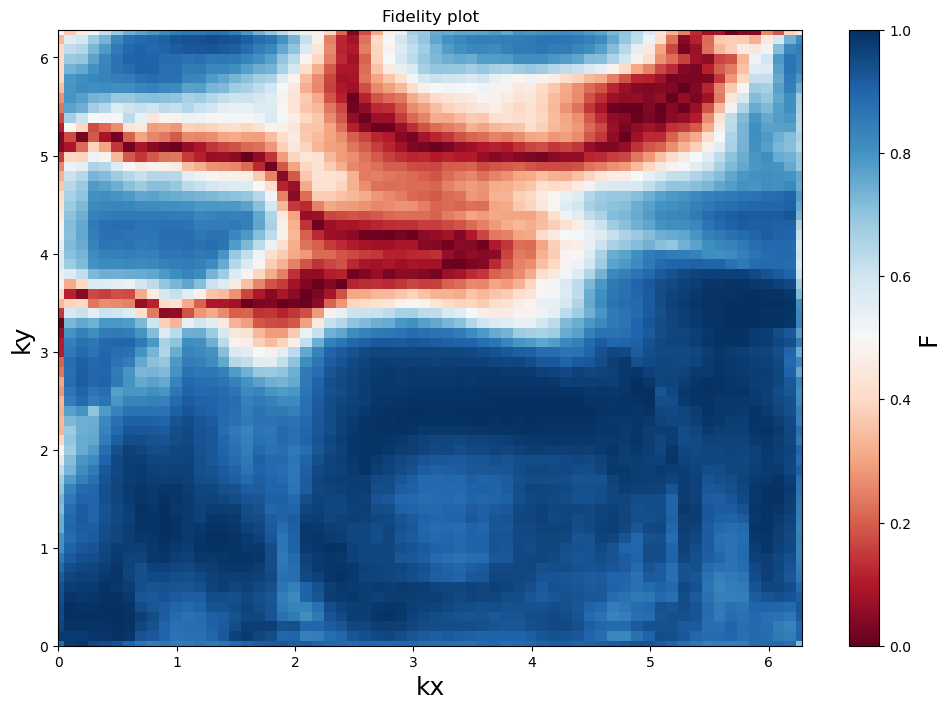

In [99]:
kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)

fig, ax = plt.subplots(figsize=(12, 8))
y,x=np.meshgrid(kxvals,kyvals)

c = ax.pcolormesh(x,y,Fvals, cmap='RdBu', vmin=0, vmax=1)
ax.set_title('Fidelity plot')

# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])

plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)

cbar=fig.colorbar(c, ax=ax)
cbar.set_label('F',fontsize=18)

plt.savefig(f'curr_fidReconstruct_{num_pix}.png')

# How does the network generalize to higher resolution data? 

# Theoretical Data

In [113]:
num_pix
np.shape(E_th_mat[:-1, :-1])

(31, 31)

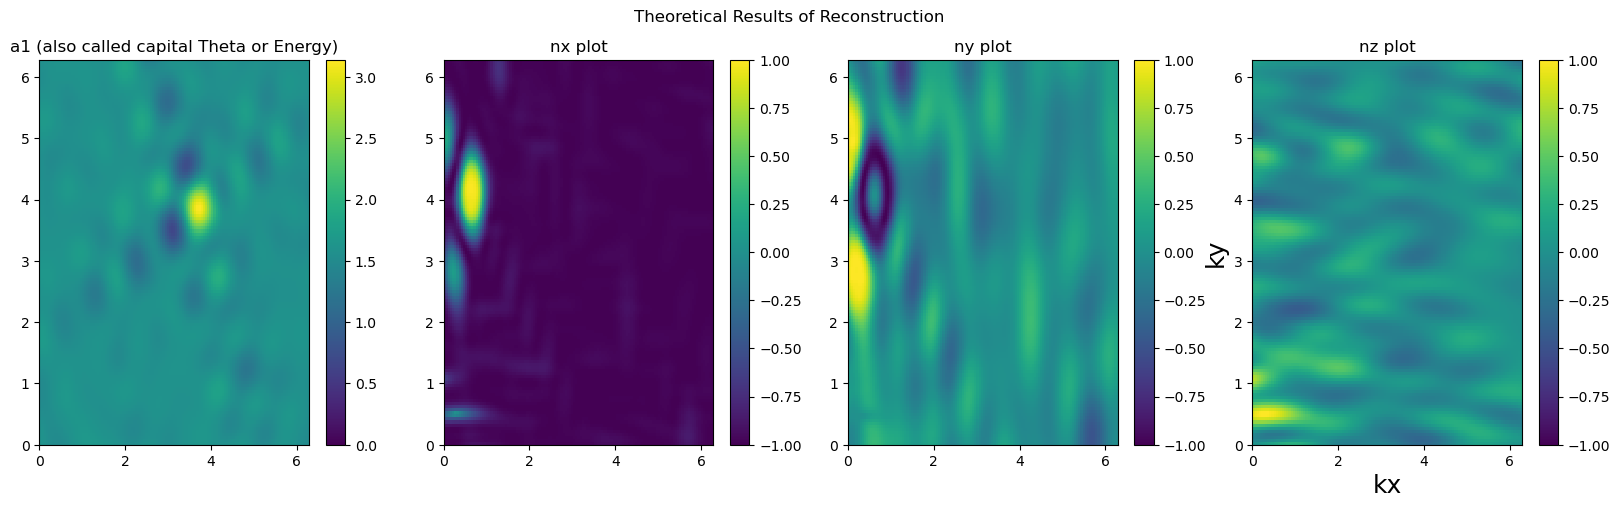

In [19]:
# Let's bind the data with some minima and maxima 

minA1 = 0
maxA1 = np.pi

minNx = -1
maxNx = 1

minNy = -1
maxNy = 1

minNz = -1
maxNz = 1

kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)

fig, ax = plt.subplots(1,4,figsize=(20, 5))
y,x=np.meshgrid(kxvals,kyvals)

plt.suptitle('Theoretical Results of Reconstruction')

c = ax[0].pcolormesh(x, y, E_th_mat[:-1, :-1], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[0])

c2 = ax[1].pcolormesh(x, y, nx_th_mat[:-1, :-1], cmap='viridis', vmin=minNx, vmax=maxNx)
ax[1].set_title('nx plot')
# set the limits of the plot to the limits of the data
ax[1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[1])

c3 = ax[2].pcolormesh(x, y, ny_th_mat, cmap='viridis', vmin=minNy, vmax=maxNy)
ax[2].set_title('ny plot')
# set the limits of the plot to the limits of the data
ax[2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[2])

c4 = ax[3].pcolormesh(x, y, nz_th_mat[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax[3].set_title('nz plot')
# set the limits of the plot to the limits of the data
ax[3].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c4, ax=ax[3])

plt.savefig(f'theoretical_{num_pix}.png')

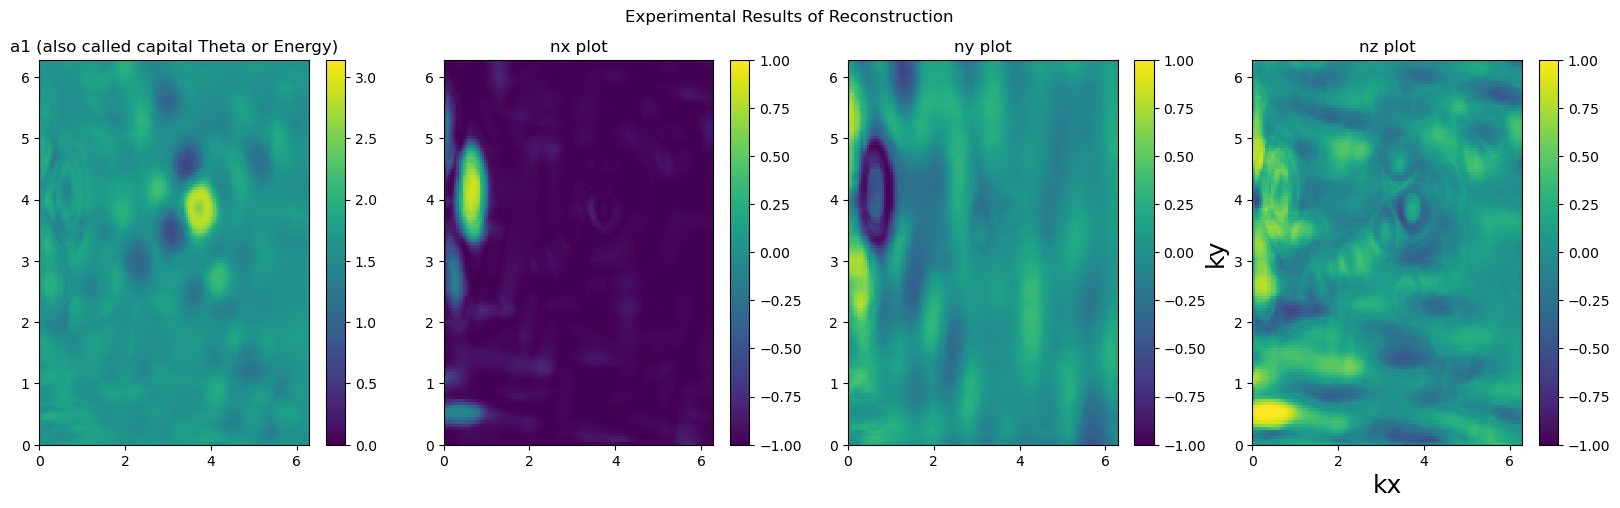

In [20]:
# Let's bind the data with some minima and maxima 

minA1 = 0
maxA1 = np.pi

minNx = -1
maxNx = 1

minNy = -1
maxNy = 1

minNz = -1
maxNz = 1

kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)

fig, ax = plt.subplots(1,4,figsize=(20, 5))
y,x=np.meshgrid(kxvals,kyvals)

plt.suptitle('Experimental Results of Reconstruction')

c = ax[0].pcolormesh(x, y, En_vect[:-1, :-1], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[0])

c2 = ax[1].pcolormesh(x, y, nx_vect[:-1, :-1], cmap='viridis', vmin=minNx, vmax=maxNx)
ax[1].set_title('nx plot')
# set the limits of the plot to the limits of the data
ax[1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[1])

c3 = ax[2].pcolormesh(x, y, ny_vect[:-1,:-1], cmap='viridis', vmin=minNy, vmax=maxNy)
ax[2].set_title('ny plot')
# set the limits of the plot to the limits of the data
ax[2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[2])

c4 = ax[3].pcolormesh(x, y, nz_vect[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax[3].set_title('nz plot')
# set the limits of the plot to the limits of the data
ax[3].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c4, ax=ax[3])

plt.savefig(f'experimental_{num_pix}.png')

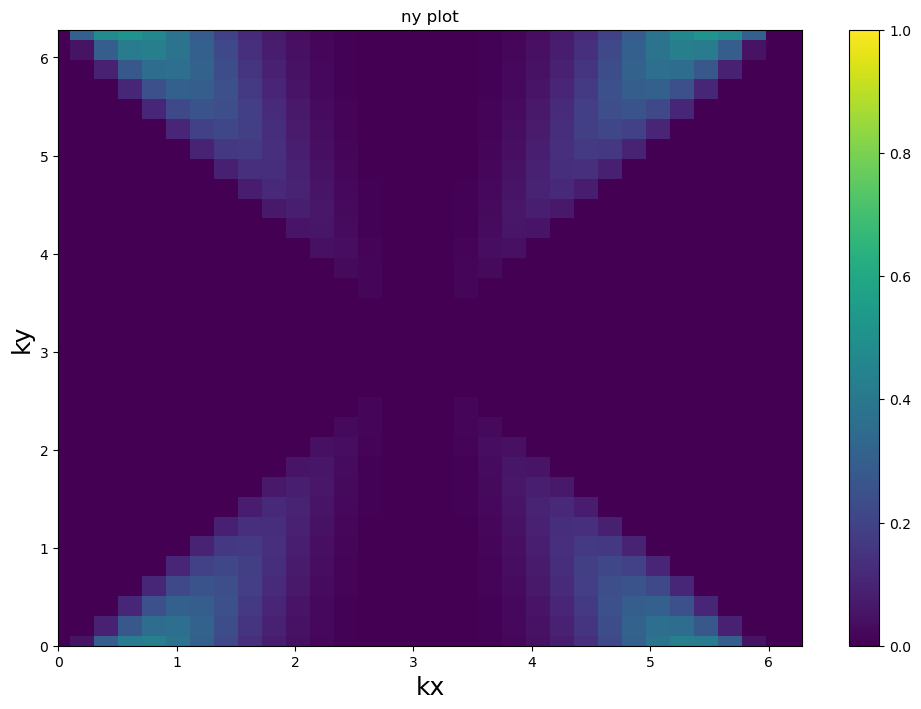

In [322]:
minNy = 0
maxNy = 1

fig, ax = plt.subplots(figsize=(12, 8))
y,x=np.meshgrid(kxvals,kyvals)

c = ax.pcolormesh(x, y, ny_th_mat, cmap='viridis', vmin=minNy, vmax=maxNy)
ax.set_title('ny plot')
# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax)

plt.savefig('a3_tho.png')

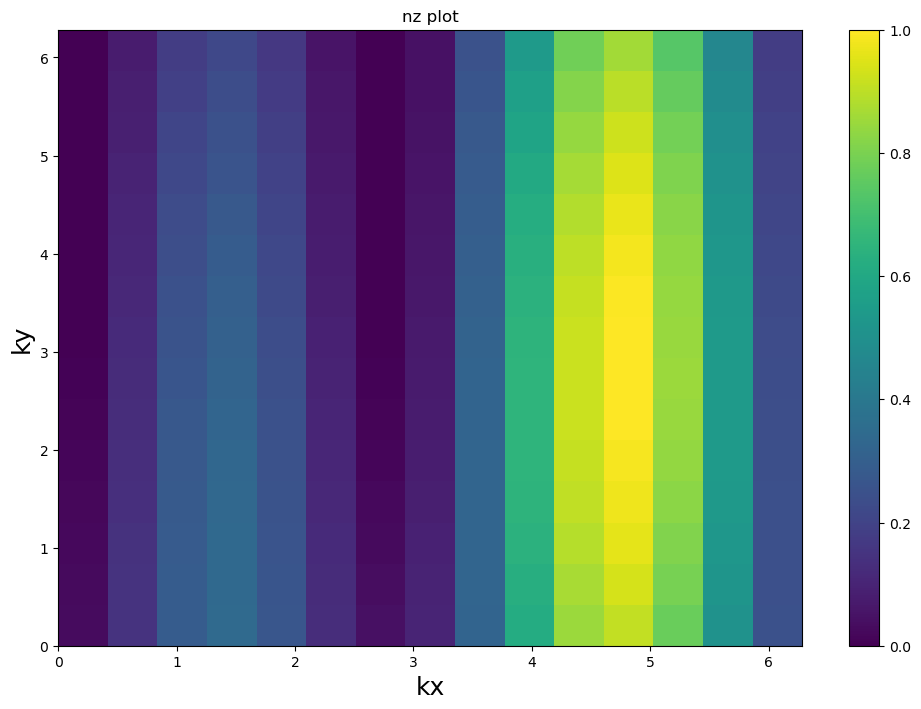

In [349]:
minNz = 0
maxNz = 1

fig, ax = plt.subplots(figsize=(12, 8))
y,x=np.meshgrid(kxvals,kyvals)

c = ax.pcolormesh(x, y, nz_th_mat[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax.set_title('nz plot')
# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax)

plt.savefig('nz_tho.png')

# Experimental Reconstruction

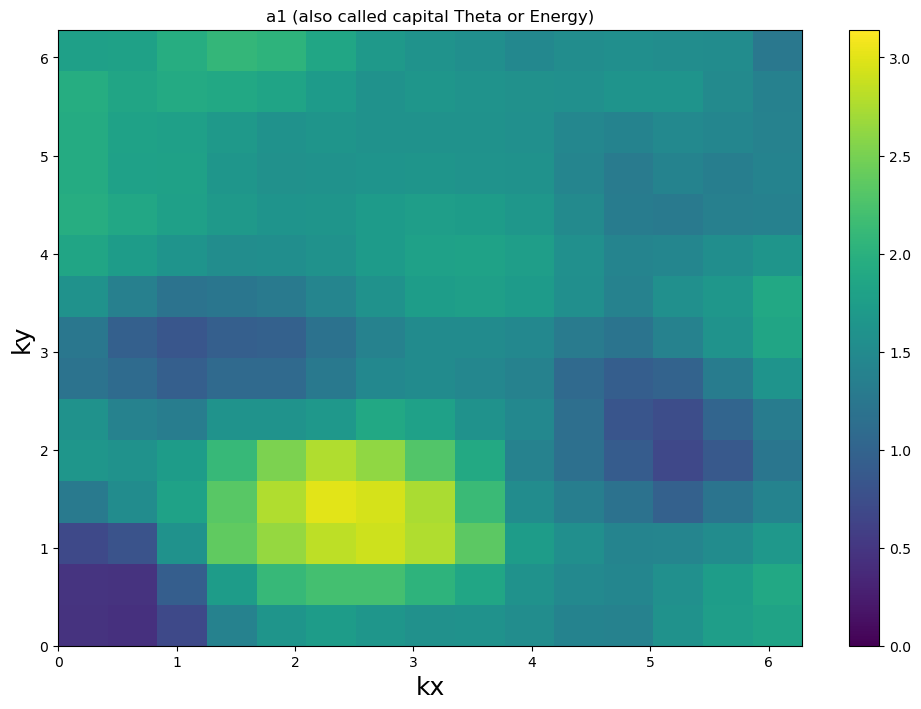

In [350]:
kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)


fig, ax = plt.subplots(figsize=(12, 8))
y,x=np.meshgrid(kxvals,kyvals)

c = ax.pcolormesh(x, y, En_vect[:-1, :-1], cmap='viridis', vmin=minA1, vmax=maxA1)
ax.set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax)

plt.savefig('a1_expt.png')

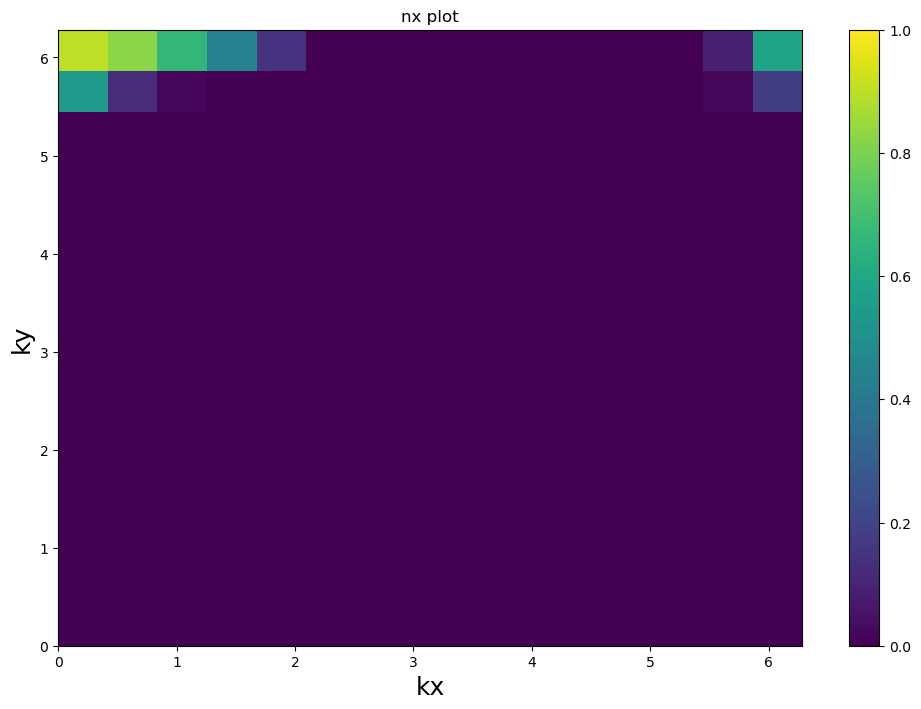

In [351]:
fig, ax = plt.subplots(figsize=(12, 8))
y,x=np.meshgrid(kxvals,kyvals)

c = ax.pcolormesh(x, y, nx_vect[:-1, :-1], cmap='viridis', vmin=minNx, vmax=maxNx)
ax.set_title('nx plot')
# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax)

plt.savefig('a2_expt.png')

In [75]:
#nx_vect
#nx_th_mat

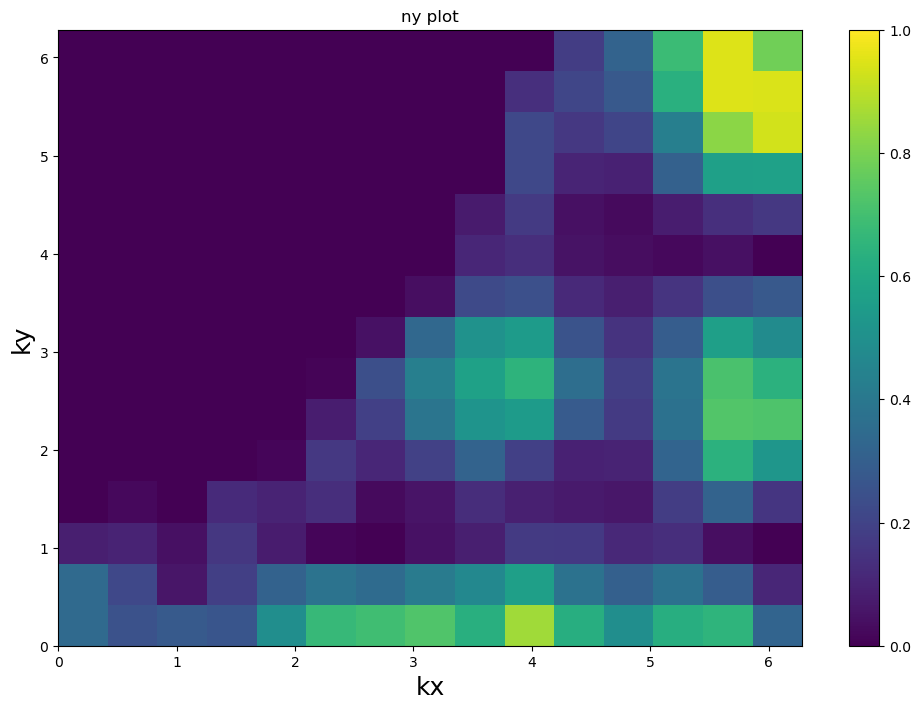

In [352]:
fig, ax = plt.subplots(figsize=(12, 8))
y,x=np.meshgrid(kxvals,kyvals)

c = ax.pcolormesh(x, y, ny_vect[:-1, :-1], cmap='viridis', vmin=minNy, vmax=maxNy)
ax.set_title('ny plot')
# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax)

plt.savefig('a3_expt.png')

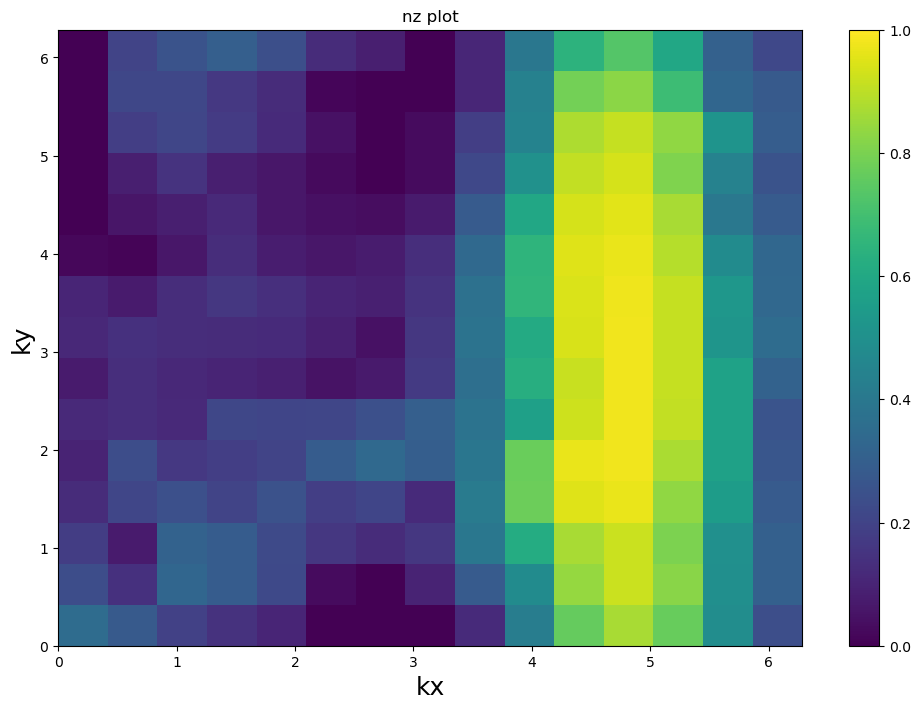

In [353]:
fig, ax = plt.subplots(figsize=(12, 8))
y,x=np.meshgrid(kxvals,kyvals)

c = ax.pcolormesh(x, y, nz_vect[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax.set_title('nz plot')
# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax)

plt.savefig('nz_expt.png')